# PROBLEM STATEMENT :
# "Analyzed student performance data for 1,000+ records using Pandas and Matplotlib, delivering insights across 6 demographic and behavioral variables. Engineered a data cleaning and transformation , performed group-level performance benchmarking, and visualized findings to support data-driven conclusions on academic success factors.

In [1]:
import pandas as pd 
import matplotlib.pyplot as plt

In [2]:
pd.set_option('display.width', 1000)

# Pandas is used for data manipulation and analysis 
# Matplotlib is used for data visualization 

# Source of Dataset -> kaggle 

# Importing  the dataset ('Student Performance new ') in a  CSV format 
# Further this dataset read and store in a variable called "data"

In [17]:
data = pd.read_csv("Student Performance new.csv")
print(data) 

     Unnamed: 0 race/ethnicity parental level of education         lunch test preparation course  math percentage  reading score percentage  writing score percentage sex
0             0        group B           bachelor's degree      standard                    none             0.72                      0.72                      0.74   F
1             1        group C                some college      standard               completed             0.69                      0.90                      0.88   F
2             2        group B             master's degree      standard                    none             0.90                      0.95                      0.93   F
3             3        group A          associate's degree  free/reduced                    none             0.47                      0.57                      0.44   M
4             4        group C                some college      standard                    none             0.76                      0.78           

#  cleaning the data first to make it understandable 

# 1.step -> renaming the column into shorter name 
# explain its need -> (For readability of data) 

In [18]:
data.rename(columns={
    'race/ethnicity' : 'race' , 
    'parental level of education' : 'parent_edu',
    'test preparation course' : 'test_prep',
    'math percentage' : 'math_score',
    'reading score percentage' :'reading_score' ,
    'writing score percentage' : 'writing_score' ,
    'sex' : 'gender'
    } , inplace=True)
print(data)

     Unnamed: 0     race          parent_edu         lunch  test_prep  math_score  reading_score  writing_score gender
0             0  group B   bachelor's degree      standard       none        0.72           0.72           0.74      F
1             1  group C        some college      standard  completed        0.69           0.90           0.88      F
2             2  group B     master's degree      standard       none        0.90           0.95           0.93      F
3             3  group A  associate's degree  free/reduced       none        0.47           0.57           0.44      M
4             4  group C        some college      standard       none        0.76           0.78           0.75      M
..          ...      ...                 ...           ...        ...         ...            ...            ...    ...
995         995  group E     master's degree      standard  completed        0.88           0.99           0.95      F
996         996  group C         high school  fr

# 2nd step  is to identify any null value present in dataset or not 
# For this we have two method - 1. .info() method -> (provide concise summary of dataset )
   #                             2. .isnull() -> (help to detect null value in dataset)
    #                            3. .isnull.sum()  -> (help to count the total null value in dataset)

In [21]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Unnamed: 0     1000 non-null   int64  
 1   race           1000 non-null   object 
 2   parent_edu     1000 non-null   object 
 3   lunch          1000 non-null   object 
 4   test_prep      1000 non-null   object 
 5   math_score     1000 non-null   float64
 6   reading_score  1000 non-null   float64
 7   writing_score  1000 non-null   float64
 8   gender         1000 non-null   object 
dtypes: float64(3), int64(1), object(5)
memory usage: 70.4+ KB
None


# Inspecting the total count of null values 

In [20]:
print(data.isnull().sum())

Unnamed: 0       0
race             0
parent_edu       0
lunch            0
test_prep        0
math_score       0
reading_score    0
writing_score    0
gender           0
dtype: int64


# Inspecting column names to identify unwanted spaces or inconsistencies
# This helps prevent errors during column operations

In [19]:
print(data.columns)

Index(['Unnamed: 0', 'race', 'parent_edu', 'lunch', 'test_prep', 'math_score', 'reading_score', 'writing_score', 'gender'], dtype='object')


# 3 step - Drop/Delete unwanted column  (.drop() method)

# data.drop(columns = ["Unnamed"] , inplace=True)  # learning - > wrong column error -> do first data analysis (how many column is there and what column name exactly there)
# Two ways to drop the specific column :
# 1. data.drop(columns=['Unnamed: 0'], inplace=True) # mentioning axis is important otherwise it throw a key error (it gets confuse from where the column is removed its from row or column )
# 2.data.drop(['Unnamed: 0'],axis = 1 ,inplace=True)
 

In [22]:
data.drop(columns=['Unnamed: 0'], inplace=True) 
data

,race,parent_edu,lunch,test_prep,math_score,reading_score,writing_score,gender
0,group B,bachelor's degree,standard,none,0.72,0.72,0.74,F
1,group C,some college,standard,completed,0.69,0.90,0.88,F
2,group B,master's degree,standard,none,0.90,0.95,0.93,F
3,group A,associate's degree,free/reduced,none,0.47,0.57,0.44,M
4,group C,some college,standard,none,0.76,0.78,0.75,M
...,...,...,...,...,...,...,...,...
995,group E,master's degree,standard,completed,0.88,0.99,0.95,F
996,group C,high school,free/reduced,none,0.62,0.55,0.55,M
997,group C,high school,free/reduced,completed,0.59,0.71,0.65,F
998,group D,some college,standard,completed,0.68,0.78,0.77,F


# 4.Analyzing what does "none" mean in the "test_prep"column 
# Insight -> 1.The "none" present in the test_prep column is valid entity or not or what does "none" means here 
#            2.Here "none" means - > Student did NOT take test preparation course

# 5. Checking for duplicate records to ensure data consistency and accuracy
# Need -> duplicate data shows inconsistency in dataset that lead wrong decision during  analysis 

In [23]:
print(data.duplicated().sum())

0


# These "0" show there is no duplicate data present in the dataset 

# Checking unique rows in specific column 
# Need -> Is to understand how many unique row present in the specific column 

In [24]:
print(data['parent_edu'].unique())

["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']


# Insight -> By applying unique()method on column ("parent_edu") we able to know that 6 unique education type  present in parent_edu

# print(data['parent_edu'].unique().sum()) 
# unique() → gives array of strings
# .sum() → concatenates all strings together 

# unique race present in race column

In [15]:
print(data['race'].unique())

['group B' 'group C' 'group A' 'group D' 'group E']


In [16]:
print(data['test_prep'].unique())

['none' 'completed']


# After cleaning -> Dataset is ready for getting Insights from it 

# 1st Insight - find overall performance of each student

In [25]:
data['avg_score'] = (data['math_score'] + data['reading_score'] + data['writing_score'])/3
data

,race,parent_edu,lunch,test_prep,math_score,reading_score,writing_score,gender,avg_score
0,group B,bachelor's degree,standard,none,0.72,0.72,0.74,F,0.726667
1,group C,some college,standard,completed,0.69,0.90,0.88,F,0.823333
2,group B,master's degree,standard,none,0.90,0.95,0.93,F,0.926667
3,group A,associate's degree,free/reduced,none,0.47,0.57,0.44,M,0.493333
4,group C,some college,standard,none,0.76,0.78,0.75,M,0.763333
...,...,...,...,...,...,...,...,...,...
995,group E,master's degree,standard,completed,0.88,0.99,0.95,F,0.940000
996,group C,high school,free/reduced,none,0.62,0.55,0.55,M,0.573333
997,group C,high school,free/reduced,completed,0.59,0.71,0.65,F,0.650000
998,group D,some college,standard,completed,0.68,0.78,0.77,F,0.743333


# Highest average among all 
# Need -> To identify the maximum average score among all 
# Result -> The highest avg_score is ->1.00

In [26]:
print(data.sort_values(by='avg_score', ascending=False).head(1))

        race         parent_edu     lunch  test_prep  math_score  reading_score  writing_score gender  avg_score
916  group E  bachelor's degree  standard  completed         1.0            1.0            1.0      M        1.0


# 2nd insight 
# Reason -> How much the the numeric columns contribute to the standard parameters (std , mean , min , max , 25%  etc ) 

In [ ]:
print(data.describe())

# 3. Finding top performer among the students

In [20]:
print(data.sort_values(by='avg_score',ascending=False).head(5))


        race          parent_edu     lunch  test_prep  math_score  reading_score  writing_score gender  avg_score
916  group E   bachelor's degree  standard  completed        1.00            1.0           1.00      M   1.000000
962  group E  associate's degree  standard       none        1.00            1.0           1.00      F   1.000000
458  group E   bachelor's degree  standard       none        1.00            1.0           1.00      F   1.000000
114  group E   bachelor's degree  standard  completed        0.99            1.0           1.00      F   0.996667
712  group D        some college  standard       none        0.98            1.0           0.99      F   0.990000


# Insight we get with the resultant dataset - > Top performing students belong to the Group E and Group D

# 4. For Group Analysis -> that tells which group scored higher among all the groups 
# step 1 - group the Groups 
# step 2 - sort the Groups in descending order 

In [ ]:
print(data['race'].unique())

In [21]:
grouped_data = data.groupby('race')['avg_score'].mean().sort_values(ascending=False)
print(grouped_data) 

race
group E    0.727524
group D    0.691794
group C    0.671317
group B    0.654684
group A    0.629925
Name: avg_score, dtype: float64


# Insight - GROUP E is the group where the average score of students is more than the average score of remaining group 
# Therefore GROUP E is best in terms of student average score among other groups 

# 5.calculating the  highest avg_score among all the groups to check the performance 
#  This avg_score is based on each group present in the dataset 
# From which we get the highest avg_score (which group avg_score is  highest )

# Logic 
# 1. arrange the "avg_score" in descending order to get the highest avg_score among all the groups 
# 2. And select the top 1 group 


In [22]:
print(data.sort_values(by='avg_score',ascending=False).head(1))

        race         parent_edu     lunch  test_prep  math_score  reading_score  writing_score gender  avg_score
916  group E  bachelor's degree  standard  completed         1.0            1.0            1.0      M        1.0


# Result -> The highest avg_score is of Group E  -> 1.00

# 6.Top 2 Groups with the highest avg_score 

In [23]:
group_avg = data.groupby('race')['avg_score'].mean()
print(group_avg)

race
group A    0.629925
group B    0.654684
group C    0.671317
group D    0.691794
group E    0.727524
Name: avg_score, dtype: float64


In [ ]:
sorted_data = group_avg.sort_values(ascending=False).head(2)
print(sorted_data)

# Insight = GROUP E have highest avg_score  and GROUP D have second highest avg_score 

#  7.- Among the group E which parent_edu gets higher average 
# This helps to identify how parent_edu affect the academic score 

#  7.- Among the group E which parent_edu gets higher average 
# This helps to identify how parent_edu affect the academic score 

# first filter the group E

In [7]:
group_e = data[data['race']=='group E']
print(group_e)

        race          parent_edu         lunch  test_prep  math_score  reading_score  writing_score gender  avg_score
32   group E     master's degree  free/reduced       none        0.56           0.72           0.65      F   0.643333
34   group E        some college      standard       none        0.97           0.87           0.82      M   0.886667
35   group E  associate's degree      standard  completed        0.81           0.81           0.79      M   0.803333
44   group E  associate's degree  free/reduced       none        0.50           0.56           0.54      F   0.533333
50   group E        some college      standard       none        0.53           0.55           0.48      M   0.520000
..       ...                 ...           ...        ...         ...            ...            ...    ...        ...
962  group E  associate's degree      standard       none        1.00           1.00           1.00      F   1.000000
968  group E  associate's degree      standard       non

In [8]:
parent_avg = group_e.groupby('parent_edu')['avg_score'].mean().sort_values(ascending=False).head(1)
print(parent_avg)

parent_edu
master's degree    0.790833
Name: avg_score, dtype: float64


# Insight = within the group E the parent_edu with master's degree have high avg_score(0.79) among all the education listed in group E

# 8. - which group performed well to getting highest avg_Score  who take the test_prep and completed it or who which do not take test_prep perform well.
# (effect of test_prep on performance across groups.)

# logic 
# first find those group who completed the test_prep 

In [ ]:
completed_test_prep = data[data['test_prep'] == 'completed' ]
print(completed_test_prep)

In [ ]:
print(completed_test_prep.groupby('race')['avg_score'].mean().sort_values(ascending=False))


# Now considering the avg_Score of the  groups who don't take any test_prep course 

In [ ]:
not_completed_test_prep = data[data['test_prep']=='none']
print(not_completed_test_prep) 

In [ ]:
print(not_completed_test_prep.groupby('race')['avg_score'].mean().sort_values(ascending=False))

# Result ->  After comparing both the avg_score of both who complete the test_prep or not take the test_prep 
# we saw that who take the test_prep and completed it acquire high avg_score then those who don'take test_prep course 


# 9. How lunch type affect the avg_score of the groups 
# 1. group by the groups on the basis of their lunch type and calculate the avg of each group (error show - > grouping based = " lunch" column -> categorical , aggregate fxn (mean)-> work on numeric data only 
  #                                                                                                 grouping -> "lunch" , "race" )



In [ ]:
# Multidimensional analysis -> In this we compare the individual lunch type of each group 

In [35]:
grouped_data_lunch = data.groupby(['race','lunch'])['avg_score'].mean()
print(grouped_data_lunch)

race     lunch       
group A  free/reduced    0.576574
         standard        0.666164
group B  free/reduced    0.609758
         standard        0.680303
group C  free/reduced    0.604123
         standard        0.708683
group D  free/reduced    0.646667
         standard        0.717465
group E  free/reduced    0.674959
         standard        0.749293
Name: avg_score, dtype: float64


# Insight -> Those who take "standard" lunch their avg_score is more as compared to those who prefer "free/reduced" lunch 

In [ ]:
# Single Dimensional Analysis -> Calculating the overall avg_score of both the lunch type and then compare which lunch type gets higher average score 

In [37]:
group_lunch = data.groupby('lunch')['avg_score'].mean()
group_lunch

lunch
free/reduced    0.621991
standard        0.708372
Name: avg_score, dtype: float64

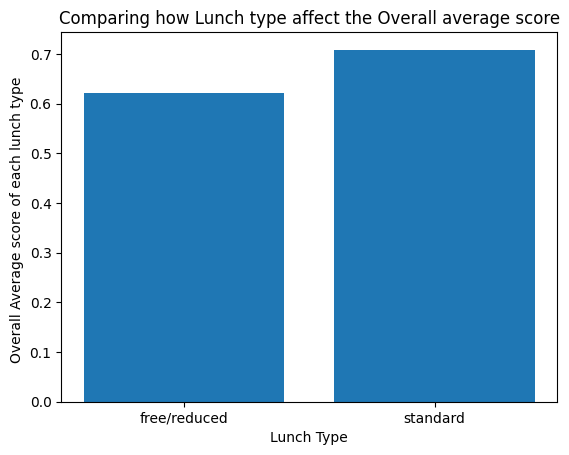

In [40]:
plt.bar(group_lunch.index , group_lunch.values)
plt.xlabel('Lunch Type')
plt.ylabel('Overall Average score of each lunch type ')
plt.title('Comparing how Lunch type affect the Overall average score')
plt.show()

# 10. Female students have higher average scores compared to male students across all subjects (math, reading, writing).
# (this is based on calculating avg_score of each subject of Male and Female )

In [29]:
avg_score_gender = data.groupby('gender')[['math_score','reading_score','writing_score']].mean()
print(avg_score_gender )

        math_score  reading_score  writing_score
gender                                          
F         0.636332       0.726081       0.724672
M         0.687282       0.654730       0.633112


# Insight - Male students perform slightly better in math, whereas female students outperform males in reading and writing.

# 11. This below avg_score is calculated based on overall avg score of all the subjects of both Male and Female 

In [29]:
avg_score = data.groupby('gender')['avg_score'].mean()
avg_score

gender
F    0.695695
M    0.658375
Name: avg_score, dtype: float64

# Insight - In overall avg_score of all the subjects Female scored higher than Male 

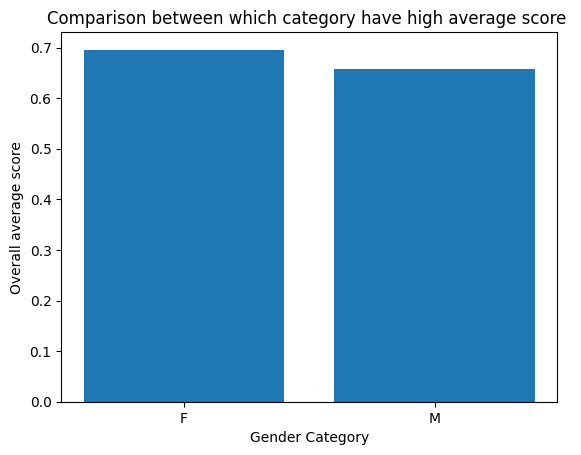

In [33]:
plt.bar(avg_score.index , avg_score.values)
plt.xlabel('Gender Category')
plt.ylabel('Overall average score')
plt.title('Comparison between which category have high average score ')
plt.show()

# CONCLUSION :
# 1. “The highest average score observed in the dataset belongs to a student in Group E.”
# 2.  “Group E is the top-performing group, followed by Group D, based on average scores.”
# 3.  “Within Group E, students whose parents have a master’s degree achieve the highest average scores.”
# 4.  “Students who completed the test preparation course consistently achieve higher average scores.”
# 5.  “Students with standard lunch tend to have higher average scores compared to those with free/reduced lunch, possibly reflecting socio-economic         influences.”
# 6.   “Performance varies by subject — males lead in math, females in reading and writing.”


# Visualizing the insights through diagrams 


# 👉 X-axis = independent variable (category or input)
# 👉 Y-axis = dependent variable (value or result)

# (X = what you are comparing)
# (Y = what you are measuring)

# 1. visualization -> Insight 2 -> BAR GRAPH (categorical data(various groups) v/s numerical data(avg_score) )

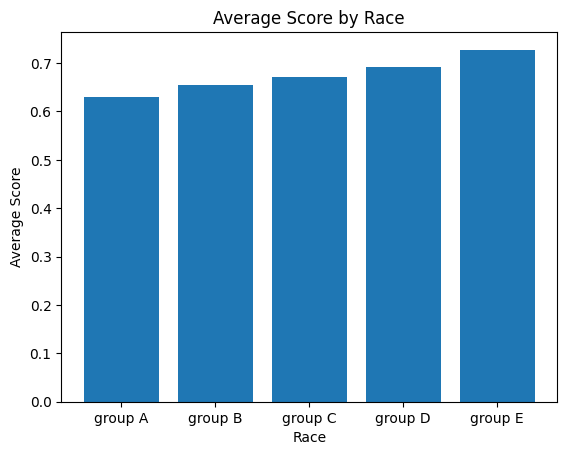

In [25]:
grouped_data = data.groupby('race')['avg_score'].mean()
plt.bar(grouped_data.index , grouped_data.values) # Actual values are passed not column name 
plt.xlabel('Race')
plt.ylabel('Average Score')
plt.title('Average Score by Race')
plt.show()


# Need unstack -> “To transform multi-level grouped data into a wide format so it can be easily visualized, especially for grouped bar charts.”

In [14]:
grouping_lunch_test_prep = data.groupby(['lunch' , 'test_prep' ])['avg_score'].mean().unstack()
grouping_lunch_test_prep

test_prep,completed,none
lunch,,
free/reduced,0.677557,0.589494
standard,0.755051,0.683022


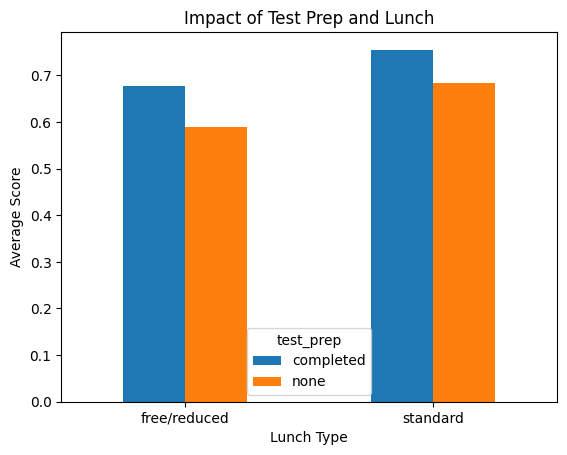

In [16]:
grouping_lunch_test_prep.plot(kind ='bar')
plt.xlabel('Lunch Type')              
plt.ylabel('Average Score')           
plt.title('Impact of Test Preparation and Lunch Type on Student Performance')
plt.xticks(rotation=0)
plt.show()


# “Students who completed the test preparation course and have standard lunch achieve the highest average scores, while those with no test preparation and free/reduced lunch perform the lowest.”